In [ ]:
# Task 1: Importing Libraries And DataSet

In [52]:
import pandas as pd # loading data
import numpy as np # mathematical calculations
import re # regular expressions for cleaning the data
import nltk # for basic
import matplotlib.pyplot as plt # visualization
from nltk.corpus import stopwords # to remove be verbs unwanted words
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



# Download required NLTK files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [54]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam (1).csv


In [55]:
df = pd.read_csv("spam.csv", encoding="latin-1")

In [56]:
df = df[['v1', 'v2']]
df.columns = ['Label', 'Email_Text']

In [57]:
df.head()

,Label,Email_Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Label       5572 non-null   object
 1   Email_Text  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [59]:
df.columns

Index(['Label', 'Email_Text'], dtype='object')

In [ ]:
# Task 2: Preprocess Email Text

In [60]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                          # Convert to lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)      # Remove numbers & punctuation
    words = text.split()                         # Split into words
    words = [word for word in words if word not in stop_words]  # Remove stopwords
    return " ".join(words)

In [61]:
df["Clean_Text"] = df["Email_Text"].apply(clean_text)

In [62]:
print(df[["Email_Text", "Clean_Text"]].head())

                                          Email_Text  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                          Clean_Text  
0  go jurong point crazy available bugis n great ...  
1                            ok lar joking wif u oni  
2  free entry wkly comp win fa cup final tkts st ...  
3                u dun say early hor u c already say  
4        nah dont think goes usf lives around though  


In [ ]:
# Task 3: Build Spam Classification Model

In [63]:
df["Label"] = df["Label"].map({"ham": 0, "spam": 1})

In [64]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["Clean_Text"])
y = df["Label"]

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [66]:
model = MultinomialNB()

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


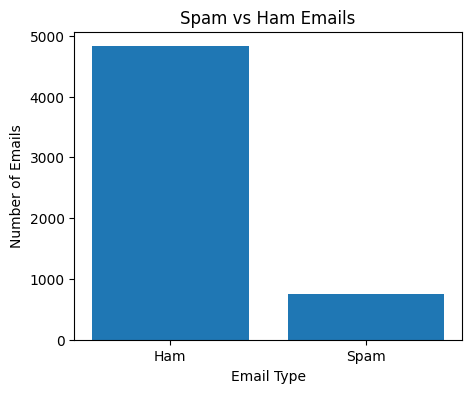

In [67]:
counts = df["Label"].value_counts()

plt.figure(figsize=(5,4))
plt.bar(["Ham", "Spam"], [counts[0], counts[1]])
plt.title("Spam vs Ham Emails")
plt.xlabel("Email Type")
plt.ylabel("Number of Emails")
plt.show()

In [ ]:
# Task 4: Evaluate Classification Accuracy

In [68]:
y_pred = model.predict(X_test)

In [69]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.967713004484305


In [70]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.76      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



In [71]:
 print(confusion_matrix(y_test, y_pred))

[[965   0]
 [ 36 114]]


In [ ]:
# Task 5: Generate Spam Analysis Report

In [72]:
spam = (df["Label"] == 1).sum()
ham = (df["Label"] == 0).sum()

print("Spam Analysis Report:")
print("Total Emails :", len(df))
print("Spam Emails :", spam)
print("Ham Emails :", ham)
print("Accuracy :", round(accuracy, 2))

print("\nConclusion:")
print("The model successfully classifies emails into Spam and Ham.")

Spam Analysis Report:
Total Emails : 5572
Spam Emails : 747
Ham Emails : 4825
Accuracy : 0.97

Conclusion:
The model successfully classifies emails into Spam and Ham.
